In [8]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import tensorflow as tf
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
# df['Species'] = iris.target_names[iris.target]

print(iris.target_names)

x = iris.data 
y = iris.target

# Preprocessing for Neural Network
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
y_encoded = to_categorical(y)

print(f"x_scaled shape: {x_scaled.shape}")
print(f"y_encoded sample: {y_encoded[0]}")

['setosa' 'versicolor' 'virginica']
x_scaled shape: (150, 4)
y_encoded sample: [1. 0. 0.]


In [10]:
# Build the Neural Network model
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Neural Network...")
model.fit(x_scaled, y_encoded, epochs=150, verbose=0)
print("Training completed.")

# Prediction
sample_input = np.array([[1.1, 1.2, 3.0, 2.3]])
sample_input_scaled = scaler.transform(sample_input)
predictions = model.predict(sample_input_scaled)
predicted_class = np.argmax(predictions, axis=1)

print(f"Prediction: {iris.target_names[predicted_class]}")

Training Neural Network...


/Users/sdsys/Files/acme/temp/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training completed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediction: ['versicolor']


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


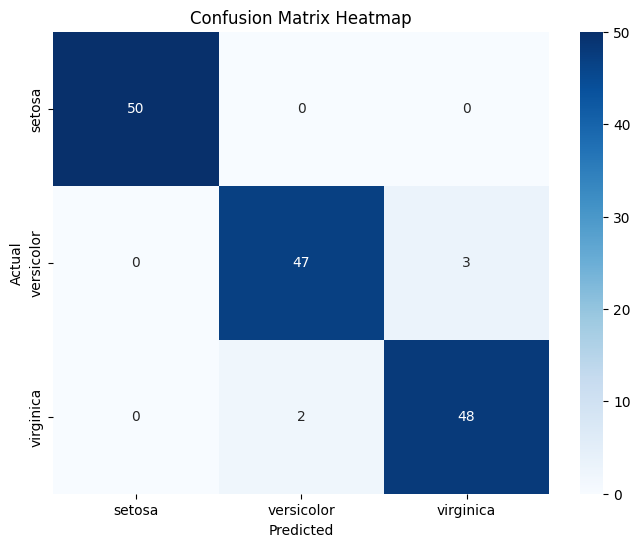

In [11]:
from sklearn.metrics import confusion_matrix

# Get predictions for all data points
y_pred_prob = model.predict(x_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()